In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg', 'pdf')
import seaborn as sns

import equinox
import optax


In [2]:
# BOOK_FIGURE_STYLE_CELL
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

try:
    import seaborn as sns
except ImportError:
    sns = None

try:
    import matplotlib_inline

    matplotlib_inline.backend_inline.set_matplotlib_formats("svg")
except Exception:
    matplotlib_inline = None

FIGURE_SIZES = {
    "full_landscape": (7.35, 4.40),
    "full_standard": (7.35, 4.90),
    "full_tall": (7.35, 5.50),
    "half_standard": (3.55, 2.55),
    "half_tall": (3.55, 3.05),
    "inset": (2.30, 1.75),
}

BOOK_COLORS = {
    "blue": "#4C78A8",
    "orange": "#F58518",
    "green": "#54A24B",
    "red": "#E45756",
    "gray": "#7F7F7F",
}

BOOK_TARGET = "web"


def setup_book_style(target="web"):
    global BOOK_TARGET
    BOOK_TARGET = target
    mpl.rcParams.update(
        {
            "figure.figsize": FIGURE_SIZES["half_standard"],
            "figure.dpi": 120,
            "savefig.dpi": 300,
            "savefig.bbox": "tight",
            "savefig.pad_inches": 0.02,
            "font.family": "sans-serif",
            "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"],
            "axes.labelsize": 9,
            "axes.titlesize": 9,
            "axes.linewidth": 0.8,
            "axes.grid": False,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "xtick.labelsize": 8,
            "ytick.labelsize": 8,
            "xtick.major.width": 0.8,
            "ytick.major.width": 0.8,
            "legend.fontsize": 8,
            "legend.frameon": False,
            "lines.linewidth": 1.5,
            "lines.markersize": 4,
            "patch.linewidth": 0.8,
            "image.cmap": "viridis",
        }
    )
    if target == "latex":
        try:
            mpl.rcParams["text.usetex"] = False
        except Exception:
            mpl.rcParams["text.usetex"] = False


def new_figure(
    size="half_standard",
    nrows=1,
    ncols=1,
    sharex=False,
    sharey=False,
    constrained=True,
    squeeze=True,
    **kwargs,
):
    fig, ax = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        sharex=sharex,
        sharey=sharey,
        constrained_layout=constrained,
        figsize=FIGURE_SIZES[size],
        squeeze=squeeze,
        **kwargs,
    )
    return fig, ax


def label_panels(axes=None, labels=None, x=0.02, y=0.98, **kwargs):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    if labels is None:
        labels = [f"({chr(97 + i)})" for i in range(len(axes))]
    default = dict(
        fontsize=9,
        fontweight="semibold",
        va="top",
        ha="left",
        transform=None,
    )
    default.update(kwargs)
    for ax, label in zip(axes, labels):
        call_kwargs = dict(default)
        if call_kwargs["transform"] is None:
            call_kwargs["transform"] = ax.transAxes
        ax.text(x, y, label, **call_kwargs)


def finalize_axes(axes=None, keep_box=False, grid=False):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        if grid:
            ax.grid(axis="y", color="0.88", linewidth=0.6)
        else:
            ax.grid(False)
        for spine in ax.spines.values():
            spine.set_linewidth(0.8)
        if keep_box:
            ax.spines["top"].set_visible(True)
            ax.spines["right"].set_visible(True)
        else:
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
    return axes


def save_book_figure(fig, basename, target="web", pdf=True, png=False):
    base = Path(basename)
    base.parent.mkdir(parents=True, exist_ok=True)
    if pdf:
        fig.savefig(base.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
    if png:
        fig.savefig(base.with_suffix(".png"), bbox_inches="tight", pad_inches=0.02)


setup_book_style(target="web")


In [3]:
import jax
import equinox as eqx

class FourierEncoding(eqx.Module):
    B: jax.Array

    @property
    def num_fourier_features(self) -> int:
        return self.B.shape[0]

    @property
    def in_size(self) -> int:
        return self.B.shape[1]
    
    @property
    def out_size(self) -> int:
        return self.B.shape[0] * 2

    def __init__(self, 
                 in_size: int, 
                 num_fourier_features: int, 
                 key: jax.random.PRNGKey, 
                 sigma: float = 1.0):
        self.B = jax.random.normal(
            key, shape=(num_fourier_features, in_size),
            dtype=jax.numpy.float32) * sigma
    
    def __call__(self, x: jax.Array, **kwargs) -> jax.Array:
        return jax.numpy.concatenate(
            [jax.numpy.cos(jax.numpy.dot(self.B, x)),
             jax.numpy.sin(jax.numpy.dot(self.B, x))],
            axis=0)
    

def train_pinn(
        loss,
        fourier_mlp,
        key,
        optimizer,
        filter_spec,
        Lx=1.0,
        Ly=1.0,
        num_collocation_residual=512,
        num_iter=10_000,
        freq=1,
    ):

    # this is new
    def new_loss(diff_model, static_model, x, y):
        comb_model = eqx.combine(diff_model, static_model)
        return loss(comb_model, x, y)

    @eqx.filter_jit
    def step(opt_state, model, xs, ys):
        # added this line
        diff_model, static_model = eqx.partition(model, filter_spec)
        # changed the loss to the new loss
        value, grads = eqx.filter_value_and_grad(new_loss)(diff_model, static_model, xs, ys)
        updates, opt_state = optimizer.update(grads, opt_state)
        model = eqx.apply_updates(model, updates)
        return model, opt_state, value
    
    opt_state = optimizer.init(eqx.filter(fourier_mlp, eqx.is_inexact_array))
    
    losses = []
    for i in range(num_iter):
        key1, key2, key = jrandom.split(key, 3)
        xb = jrandom.uniform(key1, (num_collocation_residual,), maxval=Lx)
        yb = jrandom.uniform(key2, (num_collocation_residual,), maxval=Ly)
        fourier_mlp, opt_state, value = step(opt_state, fourier_mlp, xb, yb)
        if i % freq == 0:
            losses.append(value)
            print(f"Step {i}, residual loss {value:.3e}")
    return fourier_mlp, losses

# Energy Functionals

Consider the steady-state heat equation on the rectangle $\Omega=[0,L_x]\times[0,L_y]$, with constant conductivity $k>0$, a continuous source $f$, and zero boundary temperature:

$$
\begin{aligned}
-k\Delta u &= f &&\text{in }\Omega,\\
u &=0 &&\text{on }\partial\Omega.
\end{aligned}
$$

The integrated squared residual assigns a scalar to each candidate field:

$$
R[u]=\int_\Omega(-k\Delta u-f)^2\,dx\,dy.
$$

A map from a function to a scalar is called a *functional*. For this equation, the *energy functional* is

$$
E[u]=\int_\Omega\left(\frac{k}{2}|\nabla u|^2-fu\right)\,dx\,dy.
$$

Unlike the squared residual, this energy uses only first derivatives. Its admissible fields have square-integrable values and first weak derivatives and satisfy the zero boundary condition. A weak derivative extends differentiation through integration against smooth test functions; it allows fields with corners, such as ReLU-network outputs. This admissible space is denoted $W_0^{1,2}(\Omega)$; the subscript records the zero boundary values {cite:p}`adams2003sobolev`.

Under the assumptions above, the energy has a unique minimizer in this space. The minimizer is a weak solution: it satisfies an integrated form of the heat equation, even when classical second derivatives are unavailable. A sufficiently smooth weak solution also satisfies the PDE pointwise. Restricting the candidates to a neural-network family does not guarantee a unique set of weights or successful optimization.

Let $v\in W_0^{1,2}(\Omega)$ be a perturbation that preserves the boundary values. The *first variation* measures the change in energy in direction $v$:

$$
\frac{\delta E[u]}{\delta v}
=\left.\frac{d}{d\epsilon}E[u+\epsilon v]\right|_{\epsilon=0}
=\int_\Omega(k\nabla u\cdot\nabla v-fv)\,dx\,dy.
$$

At a minimizer this expression is zero for every admissible $v$. That integrated identity is the weak heat equation; it only requires first derivatives of $u$.

If $u$ is sufficiently smooth, integration by parts gives

$$
\int_\Omega(k\nabla u\cdot\nabla v-fv)\,dx\,dy
=\int_\Omega(-k\Delta u-f)v\,dx\,dy.
$$

The boundary term vanishes because $v=0$ there. Since the identity holds for every test function, the smooth field satisfies the heat equation. This calculation interprets the weak equation in the smooth case; it does not assume that every admissible field has a classical Laplacian.

The second variation is $k\int_\Omega|\nabla v|^2\,dx\,dy$. Positive conductivity and the fixed zero boundary values make the energy strictly convex in the field, which explains uniqueness of its minimizer.

# Nondimensionalizing the Energy Functional

We scale everything like we did before:

\begin{align*}
x &\mapsto \tilde{x} = \frac{x}{L_x}, \\
y &\mapsto \tilde{y} = \frac{y}{L_y}, \\
u &\mapsto \tilde{u} = \frac{u}{u_s}, \\
f &\mapsto \tilde{f} = \frac{f}{f_s}. \\
\end{align*}

We can now directly make the change on the energy functional:

\begin{align*}
E[u] &= L_xL_y\int_{\tilde{\Omega}} \left\{ \frac{1}{2}\left[\frac{ku_s^2}{L_x^2}\left(\frac{\partial \tilde{u}}{\partial \tilde{x}}\right)^2 + \frac{ku_s^2}{L_y^2}\left(\frac{\partial \tilde{u}}{\partial \tilde{y}}\right)^2\right] - f_su_s\tilde{f}\tilde{u} \right\} \, d\tilde{x} \, d\tilde{y} \\
&= L_xL_yf_su_s \int_{\tilde{\Omega}} \left\{ \frac{1}{2}\left[\frac{ku_s}{L_x^2f_s}\left(\frac{\partial \tilde{u}}{\partial \tilde{x}}\right)^2 + \frac{ku_s}{L_y^2f_s}\left(\frac{\partial \tilde{u}}{\partial \tilde{y}}\right)^2\right] - \tilde{f}\tilde{u} \right\} \, d\tilde{x} \, d\tilde{y} \\
&= L_xL_yf_su_s \int_{\tilde{\Omega}} \left\{ \frac{1}{2}\left[k_x\left(\frac{\partial \tilde{u}}{\partial \tilde{x}}\right)^2 + k_y\left(\frac{\partial \tilde{u}}{\partial \tilde{y}}\right)^2\right] - \tilde{f}\tilde{u} \right\} \, d\tilde{x} \, d\tilde{y}, \\
&= L_xL_yf_su_s \tilde{E}[\tilde{u}],
\end{align*}

where we have defined $k_x = \frac{ku_s}{L_x^2f_s}$ and $k_y = \frac{ku_s}{L_y^2f_s}$.

We will pick $u_s$ to make the two terms inside $\tilde{E}[\tilde{u}]$ have the same order of magnitude.
So, we pick:

\begin{align*}
&\left\|k_x\left(\frac{\partial \tilde{u}}{\partial \tilde{x}}\right)^2+ k_y\left(\frac{\partial \tilde{u}}{\partial \tilde{y}}\right)^2\right\|_{\infty} = \|\tilde{f}\tilde{u}\|_{\infty}, \\
&\implies
\frac{ku_s}{f_s} \left\|L_x^{-2}\left(\frac{\partial \tilde{u}}{\partial \tilde{x}}\right)^2+ L_y^{-2}\left(\frac{\partial \tilde{u}}{\partial \tilde{y}}\right)^2\right\|_{\infty} = \|\tilde{f}\tilde{u}\|_{\infty}, \\
&\implies
u_s = \frac{f_s}{k}\|\tilde{f}\tilde{u}\|_{\infty}\left\|L_x^{-2}\left(\frac{\partial \tilde{u}}{\partial \tilde{x}}\right)^2+ L_y^{-2}\left(\frac{\partial \tilde{u}}{\partial \tilde{y}}\right)^2\right\|_{\infty}^{-1}.
\end{align*}

At the same time, we want to make both terms to be of order one.
This can be achieved by picking:

$$
\|\tilde{f}\tilde{u}\|_{\infty} = 1.
$$

or

$$
f_s = \|f(\tilde{x}L_x, \tilde{y}L_y)\tilde{u}\|_{\infty}.
$$

We evaluate the norms using the randomly initialized network and then hold the scales fixed during training. This is an initialization-dependent balancing heuristic, not a uniquely determined physical choice of units.

Start with our problem definition:

In [4]:
import jax.numpy as jnp

u0 = 500 # degrees Kelvin
k = 10.0 # thermal conductivity in W/mK
Lx = 0.1 # meters
Ly = 1.0 # meters

f = lambda x, y: 2.0 * jnp.pi ** 2 * k * u0 * (
    -Lx ** 2 * jnp.sin(jnp.pi * x / Lx) ** 2 * jnp.cos(2.0 * jnp.pi * y / Ly)
    -Ly ** 2 * jnp.sin(jnp.pi * y / Ly) ** 2 * jnp.cos(2.0 * jnp.pi * x / Lx)
) / (Lx ** 2 * Ly ** 2)

Some of the scaling:

In [5]:
to_x = lambda xt: xt * Lx
to_y = lambda yt: yt * Ly
to_xt = lambda x: x / Lx
to_yt = lambda y: y / Ly

For $u_s$, we need to parameterize the field:

In [6]:
# Make our model
import jax
import jax.random as jrandom
key = jrandom.PRNGKey(0)

key1, key2, key = jrandom.split(key, 3)
num_fourier_features = 100
width = 256
depth = 4
model = eqx.nn.Sequential([
    FourierEncoding(2, num_fourier_features, key1),
    eqx.nn.MLP(2 * num_fourier_features, 'scalar', width, depth, jax.nn.tanh, key=key2),
])
ut = lambda xt, yt, model: xt * (1 - xt) * yt * (1 - yt) * model(jnp.array([xt, yt]))

Some code to calculate infinity norms of functions using points:

In [7]:
jit_vmap = lambda g: jit(vmap(g, in_axes=(0, 0)))
infinity_norm = lambda g, xs, ys: jnp.max(jnp.abs(jit_vmap(g)(xs, ys)))

Now, we can find $f_s$:

In [8]:
from jax import vmap, jit

xs = jnp.linspace(0, Lx, 100)
ys = jnp.linspace(0, Ly, 100)
X, Y = jnp.meshgrid(xs, ys)
Xt = to_xt(X)
Yt = to_yt(Y)
Xt_flat = Xt.flatten()
Yt_flat = Yt.flatten()

fs = infinity_norm(lambda xt, yt: f(to_x(xt), to_y(yt)) * ut(xt, yt, model), Xt_flat, Yt_flat)

# The scaled version of the source
ft = lambda xt, yt: f(to_x(xt), to_y(yt)) / fs

print(f"fs = {fs:.3e}")

fs = 2.016e+04


And we can find $u_s$:

In [9]:
term1 = jit(vmap(lambda xt, yt: jnp.abs(ft(xt, yt) * ut(xt, yt, model)), in_axes=(0, 0)))(Xt_flat, Yt_flat).max()

from jax import grad
ut_x = grad(ut, 0)
ut_y = grad(ut, 1)
term2 = infinity_norm(lambda xt, yt: ut_x(xt, yt, model) ** 2 / Lx ** 2 + ut_y(xt, yt, model) **2 / Ly ** 2, Xt_flat, Yt_flat)

us = (fs * term1) / (k * term2)

print(f"us = {us:.3e}")

us = 6.231e+04


Now, we can define the scaled energy thermal conductivity:

In [10]:
kx = (k * us) / (Lx ** 2  * fs)
ky = (k * us) / (Ly ** 2  * fs)

print(f"kx = {kx:.3e}, ky = {ky:.3e}")

kx = 3.091e+03, ky = 3.091e+01


The following diagnostic uses the same x- and y-gradient coefficients as the training loss.

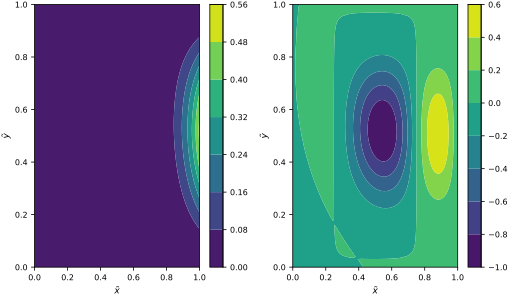

In [11]:
tE_term1 = jit(vmap(lambda xt, yt: 0.5 * (kx * ut_x(xt, yt, model) ** 2 + ky * ut_y(xt, yt, model) ** 2), in_axes=(0, 0)))
tE_term2 = jit(vmap(lambda xt, yt: ft(xt, yt) * ut(xt, yt, model), in_axes=(0, 0)))


fig, ax = plt.subplots(1,2, figsize=FIGURE_SIZES["full_landscape"])
trm1 = tE_term1(Xt_flat, Yt_flat).reshape(X.shape)
c = ax[0].contourf(Xt, Yt, trm1, cmap='viridis')
fig.colorbar(c, ax=ax[0])
ax[0].set_xlabel(r'$\tilde{x}$')
ax[0].set_ylabel(r'$\tilde{y}$')

trm2 = tE_term2(Xt_flat, Yt_flat).reshape(X.shape)
c = ax[1].contourf(Xt, Yt, trm2, cmap='viridis')
fig.colorbar(c, ax=ax[1])
ax[1].set_xlabel(r'$\tilde{x}$')
ax[1].set_ylabel(r'$\tilde{y}$')

finalize_axes(keep_box=True)
plt.tight_layout();

The two terms now have comparable scales at initialization. Training can change that balance.

## Training the Network

Let's make our new loss:

In [12]:
energy_loss = vmap(
    lambda xt, yt, model: 0.5 * (kx * ut_x(xt, yt, model) ** 2 + ky * ut_y(xt, yt, model) ** 2) - ft(xt, yt) * ut(xt, yt, model),
    in_axes=(0, 0, None),
)
pinn_loss = lambda model, xt, yt: jnp.mean(energy_loss(xt, yt, model))

In [13]:
import optax
import jax.tree_util as jtu

# Here, I am actually optimizing the Fourier coefficients
filter_spec = jtu.tree_map(lambda _: True, model)

key, subkey = jax.random.split(key)
optimizer = optax.adam(1e-3)
trained_model, losses = train_pinn(
    pinn_loss, model, subkey, optimizer, filter_spec,
    num_collocation_residual=256, num_iter=5_000, freq=100, Lx=1.0, Ly=1.0)

Step 0, residual loss 1.109e-01


Step 100, residual loss -8.265e-02


Step 200, residual loss -1.764e-01


Step 300, residual loss -2.119e-01


Step 400, residual loss -1.290e-01


...

Step 4500, residual loss -1.833e-01


Step 4600, residual loss -2.867e-01


Step 4700, residual loss -1.239e-01


Step 4800, residual loss -2.469e-01


Step 4900, residual loss -1.518e-01


Let's look at the evolution of the energy functional during training:

array([<Axes: xlabel='Iteration x 100', ylabel='Energy loss'>],
      dtype=object)

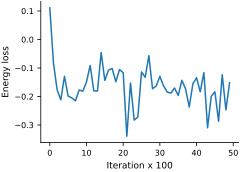

In [14]:
fig, ax = plt.subplots(figsize=FIGURE_SIZES["half_standard"])
ax.plot(losses)
ax.set_xlabel('Iteration x 100')
ax.set_ylabel('Energy loss')
finalize_axes(keep_box=False)

Panel (a) shows the neural approximation and panel (b) the exact temperature field. Both use the same grayscale range and colorbar.

findfont: Failed to find font weight semibold, now using 700.


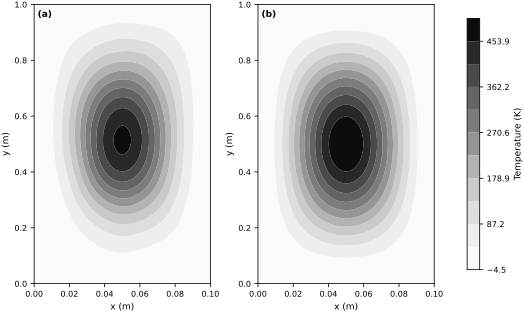

In [15]:
u_true = u0 * jnp.sin(jnp.pi * X / Lx) ** 2 * jnp.sin(jnp.pi * Y / Ly) ** 2

vtu = jit(vmap(lambda xt, yt: ut(xt, yt, trained_model)))
u_pred = vtu(Xt_flat, Yt_flat).reshape(X.shape) * us

levels = np.linspace(float(jnp.minimum(u_pred.min(), u_true.min())),
                     float(jnp.maximum(u_pred.max(), u_true.max())), 12)
fig, axes = plt.subplots(1, 2, figsize=FIGURE_SIZES["full_landscape"], layout="constrained")
for ax, values in zip(axes, [u_pred, u_true]):
    contour = ax.contourf(X, Y, values, cmap="Greys", levels=levels)
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
label_panels(axes)
fig.colorbar(contour, ax=axes, label="Temperature (K)", shrink=0.9, pad=0.06)
finalize_axes(axes, keep_box=True)
plt.show()


array([<Axes: xlabel='$\\tilde{x}$', ylabel='$\\tilde{y}$'>,
       <Axes: label='<colorbar>', ylabel='Absolute temperature error (K)'>],
      dtype=object)

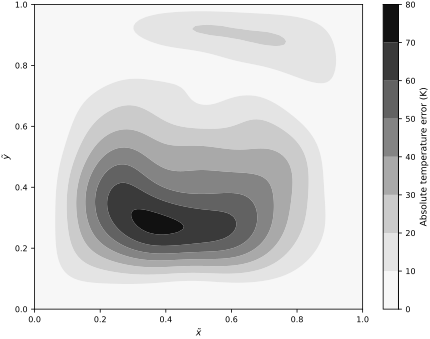

In [16]:
fig, ax = plt.subplots(figsize=FIGURE_SIZES["full_tall"])
ax.set_xlabel(r'$\tilde{x}$')
ax.set_ylabel(r'$\tilde{y}$')
c = ax.contourf(to_xt(X), to_yt(Y), jnp.abs(u_pred - u_true), cmap='Greys')
plt.colorbar(c, ax=ax, label="Absolute temperature error (K)")
finalize_axes(keep_box=True)

The error plot measures this finite training run. Accuracy depends on the network, collocation samples, and optimization budget; the energy formulation alone does not guarantee a more accurate neural approximation than residual minimization.